In [3]:
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.layers import Layer
import mediapipe as mp

from mrcnn.config import Config
from mrcnn import model as modellib
from mrcnn import visualize

# For working with images
import cv2
import numpy as np

from matplotlib import pyplot
from PIL import Image

#for a cleaner output
import warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'keras.engine'

In [ ]:
#get path to annotation file, contains coordinates of where the clothing item is in each image
bbox_file = "C:/Users/mikae/Downloads/In-shop Clothes Retrieval Benchmark-004/In-shop Clothes Retrieval Benchmark/Anno/list_bbox_inshop.txt"

# Load dataset using pandas, reads it as a dataset
df = pd.read_csv(bbox_file, delim_whitespace=True, skiprows=2, header=None)

#renaming columns for simplicity
df.columns = ['image_path', 'class_id', 'image_id', 'x1', 'y1', 'x2', 'y2']
df['class_id'] = df['image_path'].apply(lambda x: x.split('/')[2])  # e.g., "Blouses_Shirts", "Dresses"
df['class_id'] = df['class_id'].str.lower()

#display first rows
print(df.head())

# Get column names
print(df.columns)

                                          image_path        class_id  \
0  img/WOMEN/Blouses_Shirts/id_00000001/02_1_fron...  blouses_shirts   
1  img/WOMEN/Blouses_Shirts/id_00000001/02_2_side...  blouses_shirts   
2  img/WOMEN/Blouses_Shirts/id_00000001/02_3_back...  blouses_shirts   
3  img/WOMEN/Blouses_Shirts/id_00000001/02_4_full...  blouses_shirts   
4       img/WOMEN/Dresses/id_00000002/02_1_front.jpg         dresses   

   image_id   x1  y1   x2   y2  
0         1   50  49  208  235  
1         2  119  48  136  234  
2         3   50  42  213  240  
3         4   82  30  162  129  
4         1   65  45  233  252  
Index(['image_path', 'class_id', 'image_id', 'x1', 'y1', 'x2', 'y2'], dtype='object')


In [ ]:
#create the full image path
base_dir = r"C:\Users\mikae\Downloads\In-shop Clothes Retrieval Benchmark-004\In-shop Clothes Retrieval Benchmark\Anno\densepose\img_iuv"
#change image path column to full path
df['full_path'] = df['image_path'].apply(lambda x: os.path.join(base_dir, x))

In [ ]:
#important functions
#approximate body type/dimensions of images in the dataset based on x and y coords
def estimate_body_shape(row):
    width = row['x2'] - row['x1']
    height = row['y2'] - row['y1']
    aspect_ratio = width / height
    if aspect_ratio > 0.45:
        return 'curvy'
    elif aspect_ratio < 0.35:
        return 'slim'
    else:
        return 'average'

#loads and prepares each image
#we should reuse this for the user's input!!!
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path) #load image from file
    image = tf.image.decode_jpeg(image, channels=3) #decode jpeg
    image = tf.image.resize(image, [224, 224]) #resize to standard input size
    image = image / 255.0  #normalization
    return image, label #returns the image, label pair

#used for user input
def preprocess_user_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])  # Match the DeepFashion2 image size
    image = image / 255.0  # Normalize pixel values to 0-1
    return image

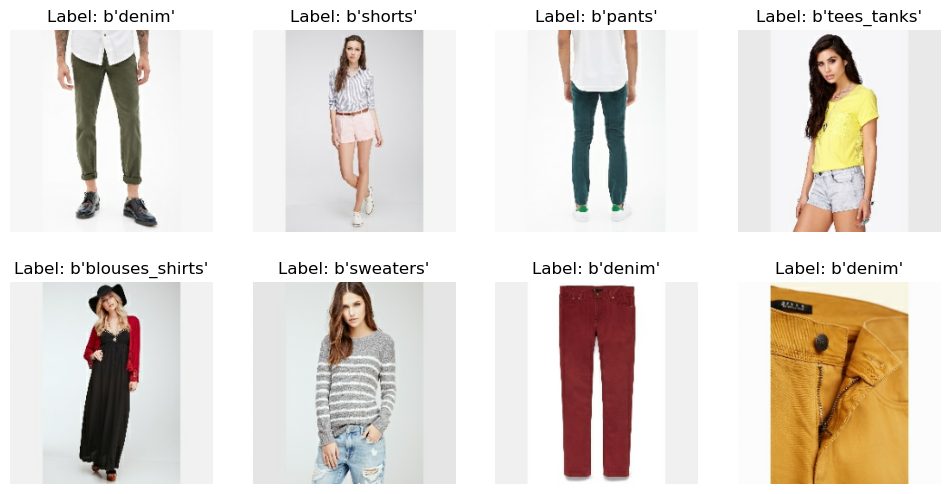

In [ ]:
# Convert columns to numpy arrays
image_paths = df['full_path'].values #get all of the image paths
labels = df['class_id'].values #get the values of class_id

#print(image_paths)
#print(labels)

#create tensorflow dataset using paths and labels, this is a paired dataset matching image_paths to labels 
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

#use loader to map the dataset, apply the image processing to every pair in the dataset
dataset = dataset.map(load_and_preprocess_image)

#shuffle the batch to sample data
dataset = dataset.shuffle(buffer_size=1000).batch(32)

#sample some data and visualize it
for images, labels in dataset.take(1):
    plt.figure(figsize=(12,6))
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(f'Label: {labels[i].numpy()}')
        plt.axis("off")


In [ ]:
#how the model should be used, sets up environment
#config for mask r cnn
class InferenceConfig(Config):
    NAME = "coco"
    NUM_CLASSES = 81  #80 object categories and one background class
    GPU_COUNT = 1 #controls batch size
    IMAGES_PER_GPU = 1 #controls batch size
    IMAGE_MIN_DIM = 800
    IMAGE_MAX_DIM = 1024 #control image resizing
    RPN_ANCHOR_SCALES = (32, 64, 128, 256, 512) #allows for detection of various sizes



In [ ]:
#create instance of config
config = InferenceConfig()

#sets mode to inference (prediction), sets directory where files and logs are saved, applies config settings to model
model = modellib.MaskRCNN(mode="inference", model_dir='./', config=config)

#apply weights for neural network
#coco has pretrained weights
model.load_weights('mask_rcnn_coco.h5', by_name=True)


In [ ]:
#make input easier, will probably end up doing fuzzy matching
clothing_aliases = {
    "dress": "dresses",
    "dresses": "dresses",
    "hoodie": "sweatshirts_hoodies",
    "sweatshirt": "sweatshirts_hoodies",
    "hoodies": "sweatshirts_hoodies",
    "graphic tee": "graphic_tees",
    "graphic t-shirt": "graphic_tees",
    "tank top": "tees_tanks",
    "tank": "tees_tanks",
    "tee": "tees_tanks",
    "t-shirt": "tees_tanks",
    "blouse": "blouses_shirts",
    "shirt": "blouses_shirts",
    "sweater": "sweaters",
    "cardigan": "cardigans",
    "jacket": "jackets_coats",
    "coat": "jackets_coats",
    "jumpsuit": "rompers_jumpsuits",
    "romper": "rompers_jumpsuits",
    "shorts": "shorts",
    "pants": "pants",
    "trousers": "pants",
    "skirt": "skirts",
    "leggings": "leggings",
    "vest": "jackets_vests",
    "suit": "suiting",
    "polo": "shirts_polos"
}



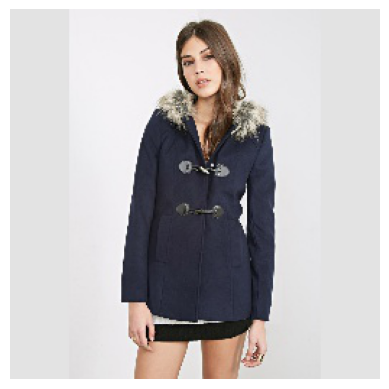

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x263FD63F580>
Recommended Image Path: C:\Users\mikae\Downloads\In-shop Clothes Retrieval Benchmark-004\In-shop Clothes Retrieval Benchmark\Anno\densepose\img_iuv\img/WOMEN/Jackets_Coats/id_00000013/03_1_front.jpg


In [ ]:
#possibly add fuzzy matching if time

#get image from user, hardcoded for now
#for live demo we will get image from google drive
#user_image_path = "C:/Users/mikae/iCloudPhotos/Photos/IMG_3670.jpeg"
#user_image = preprocess_user_image(user_image_path) #make sure this matches the format of deepfashion2 images

#input will likely look something like this:
user_pref = {
  "body_shape": "curvy",
  "clothing_type": "coat",
  "posture": "standing",
}

#add body shape estimates
df['aspect_ratio'] = (df['x2'] - df['x1']) / (df['y2'] - df['y1']).replace(0, 1)
df['body_shape'] = df.apply(estimate_body_shape, axis=1)

#normalize user input to match a class_id
user_input_clothing = user_pref["clothing_type"].strip()
standard_class = clothing_aliases.get(user_input_clothing)
if standard_class:
    user_pref["clothing_type"] = standard_class
else:
    raise ValueError(f"Unrecognized clothing type: {user_input_clothing}")

#get possible options for user
candidates_df = df[
    (df['class_id'] == user_pref['clothing_type'].lower()) &
    (df['body_shape'] == user_pref['body_shape'])
]

candidate_image_path = os.path.join(base_dir, candidates_df.iloc[0]['image_path'])  # Get the path of the first matching image
candidate_image = Image.open(candidate_image_path)  # Open the image
plt.imshow(candidate_image)
plt.axis('off')
plt.show()
print(candidate_image)

print("Recommended Image Path:", candidate_image_path)



In [ ]:
mp_pose = mp.solutions.pose
pose_model = mp_pose.Pose(static_image_mode=True)

def extract_keypoints(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Optional: Resize image to speed up detection (keeping aspect ratio)
    h, w, _ = image.shape
    if max(h, w) > 512:
        scale = 512 / max(h, w)
        image = cv2.resize(image, (int(w * scale), int(h * scale)))

    results = pose_model.process(image)

    if results.pose_landmarks:
        keypoints = [(lm.x, lm.y) for lm in results.pose_landmarks.landmark]
        return keypoints
    else:
        return None  # No person detected

def pose_similarity(user_keypoints, candidate_keypoints, important_indices):
    distances = []
    for idx in important_indices:
        if idx < len(user_keypoints) and idx < len(candidate_keypoints):
            user_pt = user_keypoints[idx]
            cand_pt = candidate_keypoints[idx]
            if user_pt and cand_pt:
                dist = np.linalg.norm(np.array(user_pt) - np.array(cand_pt))
                distances.append(dist)
    if distances:
        return np.mean(distances)
    else:
        return float('inf')


In [ ]:
user_image_path = "C:/Users/mikae/iCloudPhotos/Photos/IMG_3670.jpeg"
user_keypoints = extract_keypoints(user_image_path)

if user_keypoints is None:
    raise ValueError("No pose detected in user image.")

important_points = [11, 12, 23, 24, 25, 26, 27, 28, 31, 32]  # Mediapipe body keypoints

best_distance = float('inf')
best_candidate_path = None

candidate_paths = candidates_df['image_path'].tolist()

for relative_path in candidate_paths:
    full_path = os.path.join(base_dir, relative_path)
    candidate_keypoints = extract_keypoints(full_path)

    if candidate_keypoints is None:
        continue  # skip images with no pose

    distance = pose_similarity(user_keypoints, candidate_keypoints, important_points)

    if distance < best_distance:
        best_distance = distance
        best_candidate_path = full_path

In [ ]:
important_points = [11, 12, 23, 24, 25, 26, 27, 28, 31, 32]  # Mediapipe body keypoints

best_distance = float('inf')
best_candidate_path = None

candidate_paths = candidates_df['image_path'].tolist()

for relative_path in candidate_paths:
    full_path = os.path.join(base_dir, relative_path)
    candidate_keypoints = extract_keypoints(full_path)

    if candidate_keypoints is None:
        continue  # skip images with no pose

    distance = pose_similarity(user_keypoints, candidate_keypoints, important_points)

    if distance < best_distance:
        best_distance = distance
        best_candidate_path = full_path

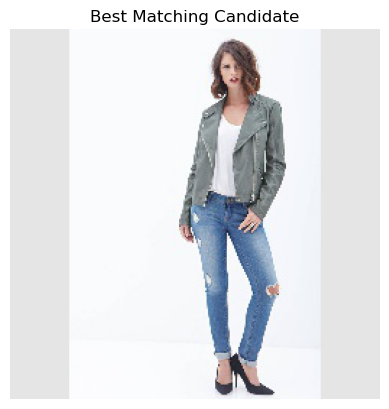

In [ ]:
if best_candidate_path:
    best_image = Image.open(best_candidate_path)
    plt.imshow(best_image)
    plt.axis('off')
    plt.title("Best Matching Candidate")
    plt.show()
else:
    print("No good matching candidate found.")

In [ ]:
'''
we still need to add options for gender, maybe color, and make sure open pose is detecting people's positioning
'''

"\nwe still need to add options for gender, maybe color, and make sure open pose is detecting people's positioning\n"